# Getting Started

Companion notebook for the [Getting Started](https://ddacs.readthedocs.io/en/latest/tutorials/getting-started/) tutorial. It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. install the package and verify the import,
2. download the small sample bundle (~22 MB) from DaRUS,
3. load the Croissant manifest and list the published RecordSets,
4. iterate one record from the simulation index,
5. open a single HDF5 simulation file and print its structure,
6. render the formed blank coloured by sheet thickness.

## Assumptions

- This notebook lives in `notebooks/` of the repository. The data directory `./data` therefore resolves to `../data` from here.
- `ddacs download --small` has been run once from the repository root, so `../data/` contains `metadata.json`, `process_parameters.csv`, and the bundled sample zip.

## 1. Install and verify

Run once per environment from a terminal:

```bash
pip install ddacs           # core
pip install ddacs[torch]    # optional, for the PyTorch adapter
```

For hardware-specific PyTorch builds (CUDA, ROCm, MPS) install PyTorch first from [pytorch.org](https://pytorch.org/get-started/locally/) and then `pip install ddacs` without the extra; the package does not pin PyTorch so an existing wheel is preserved.

Verifying that the import works also confirms the version this notebook was written against.

In [1]:
import ddacs
print('ddacs', ddacs.__version__)

ddacs 3.1.3


## 2. Download the sample bundle

From the **repository root** (not from inside `notebooks/`):

```bash
ddacs download --small
```

The command writes `metadata.json`, `process_parameters.csv`, and the bundled sample simulation zip (`258864.zip`) into `./data/`. The zips are not extracted; `mlcroissant` reads HDF5 members in place via the `zipfile` module so there is no second copy on disk.

Defining `DATA_DIR` and the sample `sim_id` here once keeps the rest of the notebook readable.

In [2]:
from pathlib import Path

DATA_DIR = Path('../data')      # this notebook lives under notebooks/, so go up one level
# DATA_DIR = Path('./data')     # uncomment instead when running from the repository root
sim_id   = 258864              # the bundled sample simulation

## 3. Load the dataset

`ddacs.load(data_dir=...)` returns an `mlcroissant.Dataset`. Internally it:

1. reads `metadata.json` from `data_dir`,
2. scans `data_dir` for files referenced in the manifest's distribution and registers their local paths so `mlcroissant` skips re-downloading,
3. parses the JSON-LD into a graph of `RecordSet`s, `FileObject`s, and `FileSet`s.

Listing the published RecordSets shows which task-specific views the dataset already ships. Each one selects a fixed set of fields suitable for one ML target (e.g. springback prediction, forming snapshot).

In [3]:
ds = ddacs.load(data_dir=DATA_DIR)
print('dataset name:', ds.metadata.name)
print('record sets:')
for rs in ds.metadata.record_sets:
    print(f'  {rs.id}')

dataset name: DDACS
record sets:
  process-parameters
  field-map
  simulation-provenance
  springback-minimal
  springback-prediction
  forming-snapshot
  cutting-view


## 4. Iterate one record from the simulation index

The `process-parameters` RecordSet is the index of the dataset: one row per simulation, with every column of `process_parameters.csv` exposed as a named field. Iterating one record is a quick smoke test that the manifest and the local CSV are wired up correctly, and it shows what the per-simulation metadata looks like before we touch any HDF5.

In [4]:
for n, rec in enumerate(ds.records('process-parameters'), start=1):
    if n == 1:
        for k, v in rec.items():
            print(f'{k:42s} = {v}')
    if n >= 1:
        break

process-parameters/index                   = 16039
process-parameters/geometry                = b'rectangular'
process-parameters/curvature_radius        = 30.0
process-parameters/bottom_radius           = 5.0
process-parameters/wall_angle              = 10.0
process-parameters/material_scaling_factor = 0.9
process-parameters/sheet_metal_thickness   = 0.95
process-parameters/friction_coefficient    = 0.05
process-parameters/blankholder_force       = 100000.0
process-parameters/split                   = b'train'
process-parameters/rddac                   = False


## 5. Inspect one simulation

`ddacs.open_h5(sim_id, data_dir=...)` is the single-simulation escape hatch. It:

1. looks at the manifest's distribution to find the zip that contains `<sim_id>.h5`,
2. reads the HDF5 member into an in-memory `BytesIO` (~20 MB),
3. returns an `h5py.File` opened on the buffer in read-only mode.

Listing the keys of `OP10/blank` is a quick way to see what arrays the workpiece group carries; `ddacs.inspect_h5` prints the full hierarchy in a tree (lines starting with `@` are HDF5 attributes, trailing `/` marks a group, bare names show shape and dtype).

In [5]:
with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    print(list(f['OP10/blank'].keys()))

['element_shell_bending_moment', 'element_shell_effective_plastic_strain', 'element_shell_effective_plastic_strain_all_ipt', 'element_shell_ids', 'element_shell_internal_energy', 'element_shell_node_ids', 'element_shell_node_indexes', 'element_shell_normal_force', 'element_shell_part_indexes', 'element_shell_shear_force', 'element_shell_strain', 'element_shell_stress', 'element_shell_stress_all_ipt', 'element_shell_stress_all_ipt_thickness', 'element_shell_thickness', 'element_shell_unknown_variables', 'node_acceleration', 'node_coordinates', 'node_displacement', 'node_ids', 'node_velocity']


In [6]:
with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    ddacs.inspect_h5(f)

├── @blankholder_force = 250000.0
├── @bottom_radius = 5.0
├── @curvature_radius = 50.0
├── @friction_coefficient = 0.05
├── @geometry = concave
├── @index = 258864
├── @material_scaling_factor = 1.075
├── @sheet_metal_thickness = 0.99
├── @wall_angle = 10.0
├── OP10/
│   ├── binder/
│   │   ├── element_shell_ids  (134,) int64
│   │   ├── element_shell_node_indexes  (134, 4) int64
│   │   ├── element_shell_part_indexes  (134,) int64
│   │   ├── node_acceleration  (3, 146, 3) float64
│   │   ├── node_coordinates  (146, 3) float64
│   │   ├── node_displacement  (3, 146, 3) float64
│   │   ├── node_ids  (146,) int64
│   │   └── node_velocity  (3, 146, 3) float64
│   ├── blank/
│   │   ├── element_shell_bending_moment  (3, 11025, 3) float64
│   │   ├── element_shell_effective_plastic_strain  (4, 11025, 3) float64
│   │   ├── element_shell_effective_plastic_strain_all_ipt  (11025, 7) float64
│   │   ├── element_shell_ids  (11025,) int64
│   │   ├── element_shell_internal_energy  (3, 11025) 

## 6. First plot

The next cell renders the formed blank coloured by sheet thickness at the final OP10 timestep (after springback). Three pieces of data are read from the HDF5 file:

- **`nodes`** : node positions. The dataset `OP10/blank/node_displacement` has shape `(t=4, n_nodes, 3)`, one position per timestep; selecting `[-1]` keeps the configuration after springback.
- **`faces`** : element connectivity. `OP10/blank/element_shell_node_indexes` has shape `(n_elements, 4)` because each shell is a quadrilateral of four node indices. There is **no time axis**: which nodes are connected by which element never changes during a simulation, so the array is read whole with `[:]`.
- **`thickness`** : current shell thickness. `OP10/blank/element_shell_thickness` has shape `(t=4, n_elements)`, again sliced with `[-1]` to match the post-springback state.

Three notable plotting options:

- `FALSE_COLOR_CMAP` : the Falschfarbenbild diverging colormap (red lower bound, green centre, blue upper bound). Paired with `vmin = nominal - delta`, `vmax = nominal + delta` so the green band lands on the nominal sheet thickness and colour deviations read as thinning (red) or thickening (blue).
- **Quarter-symmetric model**: OP10 only meshes one quadrant of the cup; the other three are implied by symmetry boundary conditions. To render the full cup, pass `mirror=True`, which reflects across `x=0` and `y=0` and reverses face winding on each reflection so the lighting stays consistent.
- ISO 80000-2 axis labels : variables italic, units upright. `ddacs.plot_mesh` applies this automatically.

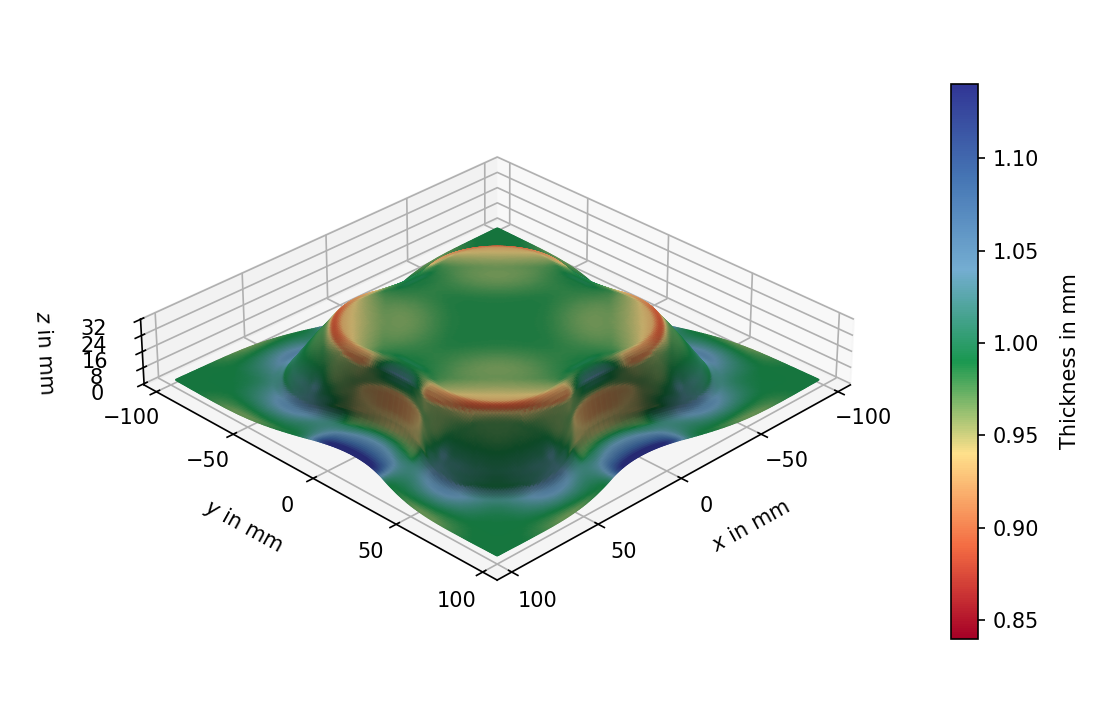

In [7]:
import matplotlib.pyplot as plt
import ddacs
from ddacs.visualization import FALSE_COLOR_CMAP

with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    nodes     = f['OP10/blank/node_displacement'][-1]          # (n_nodes, 3) at final OP10 step
    faces     = f['OP10/blank/element_shell_node_indexes'][:]  # (n_elements, 4) : time invariant
    thickness = f['OP10/blank/element_shell_thickness'][-1]    # (n_elements,) at final OP10 step
    nominal   = float(f.attrs['sheet_metal_thickness'])         # 0.99 mm for this sim

half_range = 0.15
ax, cbar = ddacs.plot_mesh(
    nodes, faces,
    values=thickness,
    cmap=FALSE_COLOR_CMAP,
    vmin=nominal - half_range,
    vmax=nominal + half_range,
    colorbar_label='Thickness in mm',
    mirror=True,
)
plt.show()